# Day 3 - RF vs XGBoost Credit Risk Modeling 
# Credit Risk Model (UCI Credit Card Dataset)

## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://huggingface.co/datasets/scikit-learn/credit-card-clients/resolve/main/UCI_Credit_Card.csv"
df = pd.read_csv(url)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.shape

(30000, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 2. Train/Test split and feature/target setup

In [6]:
target_col = 'default.payment.next.month'
X = df.drop(columns=[target_col, 'ID'])
y = df[target_col]

In [7]:
X.shape, y.shape

((30000, 23), (30000,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
X_train.shape, X_test.shape

((24000, 23), (6000, 23))

## 3. Baseline: Logistic Regression

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict_proba(X_test_scaled)[:,1]
auc_lr = roc_auc_score(y_test, y_pred_lr)
print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.7076355036089734


## 4. Random Forest Model

In [11]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42, 
    n_jobs=1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, y_pred_rf)
print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.7620415892674024


## 5. XGBoost Model

In [12]:
xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_lambda = 1.0,
    reg_alpha = 0.0,
    objective = "binary:logistic",
    eval_metric = 'auc',
    random_state = 42, 
    n_jobs = 1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict_proba(X_test)[:,1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
print("XGBoost AUC:", auc_xgb)

XGBoost AUC: 0.7748914663289616


## 6. Model Comparison

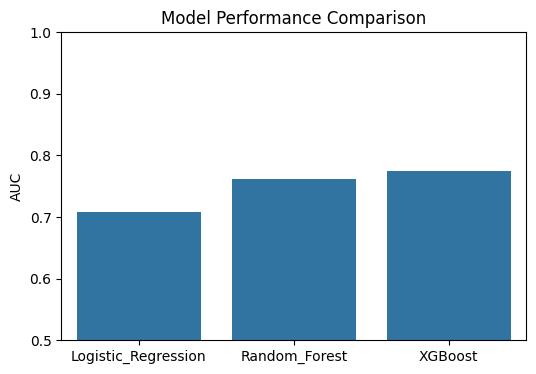

In [13]:
model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(6,4))
sns.barplot(x=model_names, y=auc_scores)
plt.ylabel("AUC")
plt.title("Model Performance Comparison")
plt.ylim(0.5, 1.0)
plt.show()

Interpretation (PM lens):

LR: baseline, linear, interpretable.

RF: better AUC, robust, less tuning.

XGB: highest AUC, more complex, needs tuning but best for production/tabular.

## 7. Feature Importance (Random Forest vs XGBoost)

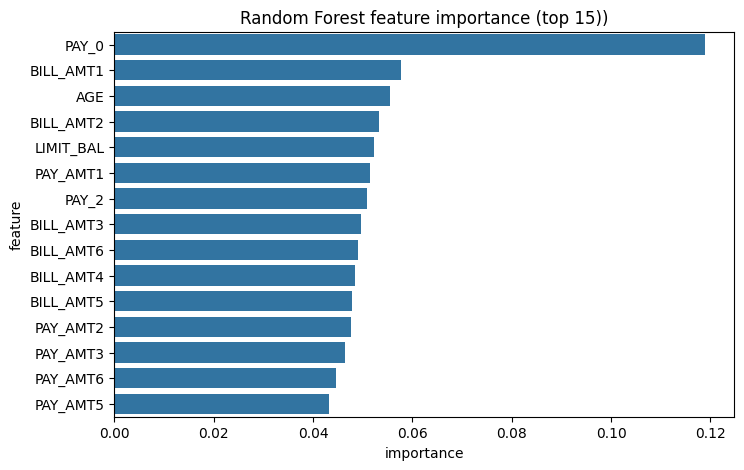

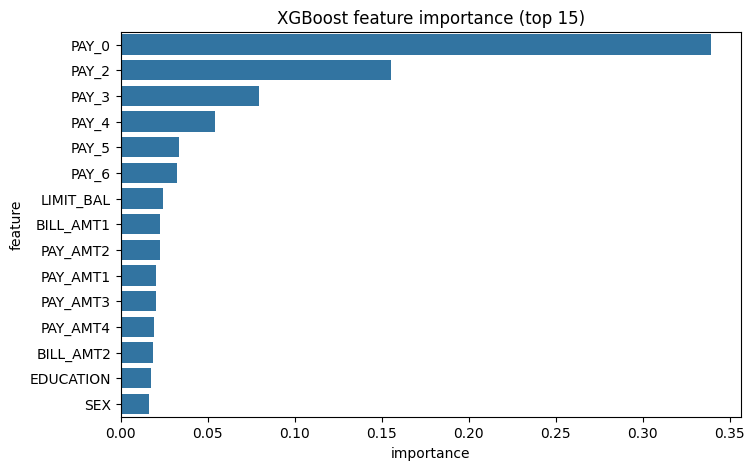

In [16]:
# Random Forest feature importance
rf_importances = rf.feature_importances_
rf_imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance":rf_importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=rf_imp_df.head(15), x='importance', y='feature')
plt.title('Random Forest feature importance (top 15))')
plt.show()

# XGBoost feature importance
xgb_importances = xgb.feature_importances_
xgb_imp_df = pd.DataFrame({
    "feature":X.columns,
    "importance":xgb_importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=xgb_imp_df.head(15), x='importance', y='feature')
plt.title('XGBoost feature importance (top 15)')
plt.show()

Random Forest distributes importance across stable, continuous features like bill amounts and age, because it builds independent trees and relies on impurity reduction.
XGBoost concentrates importance on delinquency variables like PAY_0, PAY_1, PAY_2 because boosting focuses on residual errors, and these ordinal features explain the remaining loss most effectively.
The difference is expected and reflects the underlying mechanics of bagging vs boosting.

## 8. Day 3 Summary

#### 1. Performance Summary
Our three models show a clear progression in predictive power:

Logistic Regression (AUC = 0.70)  
Establishes a transparent baseline. Captures linear relationships but misses nonlinear interactions.

Random Forest (AUC = 0.76)  
Strong improvement driven by nonlinear splits and ensemble averaging. More robust to noise and feature interactions.

XGBoost (AUC = 0.77)  
Best-performing model. Gradient boosting reduces bias by sequentially correcting residual errors, enabling finer decision boundaries.

PM takeaway:  
XGBoost provides the strongest ranking of risky vs. safe customers, but Random Forest offers stability and simplicity. Logistic Regression remains valuable for regulatory transparency.

#### 2. Why Random Forest and XGBoost Highlight Different Features
Your observed feature importance patterns are exactly what we expect given the mechanics of each algorithm.

Random Forest Top Features: PAY_0, BILL_AMT1, AGE
This makes sense because Random Forest:

builds many independent trees

selects splits based on impurity reduction

tends to favor continuous variables (like BILL_AMT1) because they offer many possible split points

often elevates stable demographic features like AGE

Interpretation:  
Random Forest spreads importance across broad, stable predictors that consistently reduce impurity across many trees.

XGBoost Top Features: PAY_0, PAY_1, PAY_2
This is also expected because XGBoost:

builds trees sequentially, each one correcting the previous model’s errors

uses gradient + Hessian to choose splits

aggressively focuses on features with strong monotonic signals

delinquency variables (PAY_0, PAY_1, PAY_2) explain residuals extremely well

Interpretation:  
XGBoost concentrates importance on ordinal delinquency indicators because they consistently reduce loss across boosting rounds. These variables are historically the strongest predictors of credit default.

#### 3. Why the Models Disagree — and Why That’s Good
Random Forest and XGBoost represent two different philosophies:

Random Forest (bagging):  
“Build many independent trees and average them.”
→ favors continuous, stable features
→ distributes importance more evenly

XGBoost (boosting):  
“Build trees that fix the remaining errors.”
→ focuses on the strongest directional signals
→ concentrates importance on delinquency history

PM takeaway:  
The difference in feature importance is not a problem — it’s a signal that each model is leveraging its strengths. Both patterns are consistent with industry expectations for credit risk.

#### 4. Business Interpretation
Delinquency history (PAY_0, PAY_1, PAY_2) is the strongest predictor of future default.

Bill amounts and age provide secondary stability and segmentation.

The models agree on the core risk drivers, even if they rank them differently.

PM takeaway:  
The model outputs align with domain intuition: recent payment behavior is the most powerful indicator of credit risk.

#### 5. Recommendation
Use XGBoost as the challenger model for highest predictive power.

Use Random Forest as a stable benchmark for production deployment.

Use Logistic Regression for regulatory discussions and coefficient‑level interpretability.